# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

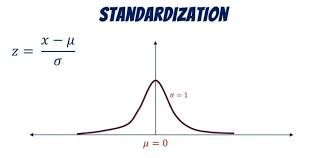


**Contributor: Milliam — Data loading, cleaning, missing-value handling, encoding, and standardization**

# Formative Assignment: Advanced Linear Algebra (PCA)

This notebook implements Principal Component Analysis (PCA) on the Life Expectancy dataset.

### Assignment Requirements

1. Display outputs for each code cell when submitting.
2. Do not write all code in one cell.
3. NumPy is used for the PCA calculations.
4. The dataset is cleaned, standardized, and reduced using PCA.
5. The number of principal components is selected based on explained variance.

In [21]:
# Step 1: Load, Clean and Standardize the Data

import numpy as np

# Load the dataset
raw = np.genfromtxt(
    "Life Expectancy Data.csv",
    delimiter=",",
    dtype=str,
    encoding="utf-8"
)

# Remove extra spaces
header = np.char.strip(raw[0])
body = np.char.strip(raw[1:])

# Display column names
print("Column names:")
print(header)

# Display first 5 rows
print("\nFirst 5 rows:")
print(body[:5])

# Identify non-numeric columns
country_index = np.where(header == "Country")[0][0]
status_index = np.where(header == "Status")[0][0]

print("\nNon-numeric columns:")
print(header[[country_index, status_index]])

# Encode Status:
# Developed = 1
# Developing = 0
status = np.where(
    body[:, status_index] == "Developed",
    1.0,
    0.0
)

# Select numerical columns
numeric_indices = np.array([
    i for i in range(len(header))
    if i != country_index and i != status_index
])

numeric_data = body[:, numeric_indices]

# Convert empty values to NaN
numeric_data[numeric_data == ""] = "nan"

# Convert numerical data to floats
numeric_data = numeric_data.astype(float)

# Count missing values
missing_values = np.isnan(numeric_data).sum(axis=0)

print("\nMissing values by numerical column:")

for name, count in zip(
    header[numeric_indices],
    missing_values
):
    print(name, ":", count)

# Replace missing values with column means
column_means = np.nanmean(
    numeric_data,
    axis=0
)

rows, columns = np.where(
    np.isnan(numeric_data)
)

numeric_data[rows, columns] = column_means[columns]

# Add encoded Status
clean_data = np.column_stack(
    (numeric_data, status)
)

print("\nCleaned data shape:")
print(clean_data.shape)

# Standardize the data
means = np.mean(
    clean_data,
    axis=0
)

stds = np.std(
    clean_data,
    axis=0
)

standardized_data = (
    clean_data - means
) / stds

print("\nFirst 5 rows of standardized data:")
print(standardized_data[:5])

print("\nMean after standardization:")
print(np.mean(standardized_data, axis=0))

print("\nStandard deviation after standardization:")
print(np.std(standardized_data, axis=0))

Column names:
['Country' 'Year' 'Status' 'Life expectancy' 'Adult Mortality'
 'infant deaths' 'Alcohol' 'percentage expenditure' 'Hepatitis B'
 'Measles' 'BMI' 'under-five deaths' 'Polio' 'Total expenditure'
 'Diphtheria' 'HIV/AIDS' 'GDP' 'Population' 'thinness  1-19 years'
 'thinness 5-9 years' 'Income composition of resources' 'Schooling']

First 5 rows:
[['Afghanistan' '2015' 'Developing' '65' '263' '62' '0.01' '71.27962362'
  '65' '1154' '19.1' '83' '6' '8.16' '65' '0.1' '584.25921' '33736494'
  '17.2' '17.3' '0.479' '10.1']
 ['Afghanistan' '2014' 'Developing' '59.9' '271' '64' '0.01'
  '73.52358168' '62' '492' '18.6' '86' '58' '8.18' '62' '0.1'
  '612.696514' '327582' '17.5' '17.5' '0.476' '10']
 ['Afghanistan' '2013' 'Developing' '59.9' '268' '66' '0.01'
  '73.21924272' '64' '430' '18.1' '89' '62' '8.13' '64' '0.1'
  '631.744976' '31731688' '17.7' '17.7' '0.47' '9.9']
 ['Afghanistan' '2012' 'Developing' '59.5' '272' '69' '0.01' '78.1842153'
  '67' '2787' '17.6' '93' '67' '8.52' '

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [22]:
# Step 3: Calculate the Covariance Matrix

cov_matrix = np.cov(
    standardized_data,
    rowvar=False
)

print("Covariance Matrix:")
print(cov_matrix)

Covariance Matrix:
[[ 1.00034048  0.16968034 -0.07888762 -0.03742766 -0.04818399  0.03141067
   0.0894287  -0.08252106  0.10836359 -0.04295161  0.09385153  0.08188801
   0.13389894 -0.13978894  0.09338262  0.01495572 -0.04760834 -0.05064394
   0.23641364  0.20354047 -0.00186492]
 [ 0.16968034  1.00034048 -0.69659641 -0.19660192  0.39173167  0.38192117
   0.20384082 -0.15762747  0.55944572 -0.22257878  0.46173093  0.20805144
   0.47558026 -0.55664628  0.43063959 -0.01964439 -0.47232264 -0.46678809
   0.69271858  0.71530981  0.48212644]
 [-0.07888762 -0.69659641  1.00034048  0.07877394 -0.19047264 -0.2428962
  -0.1386381   0.03118466 -0.38157929  0.09416714 -0.27278642 -0.11091229
  -0.27310684  0.52390524 -0.27714725 -0.01250571  0.29996477  0.30547038
  -0.44021188 -0.4352566  -0.31527802]
 [-0.03742766 -0.19660192  0.07877394  1.00034048 -0.11385102 -0.08564137
  -0.17884426  0.50129897 -0.22729733  0.99696822 -0.17073187 -0.12660721
  -0.17521595  0.02523991 -0.10714551  0.54870843  

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

The covariance matrix shows how the different features in the dataset vary in relation to each other. It is needed in PCA to identify relationships between features. The covariance matrix is also used for eigenvalue and eigenvector calculations. The eigenvectors determine the principal component directions, while the eigenvalues show the amount of variance captured by each direction.

Step 3: Calculate the Covariance Matrix

Explanation...

Contributor: Gasana — Covariance matrix implementation

[existing covariance matrix code]

In [39]:
# Task 3: Benchmark PCA Projection Performance

import time

# Start timing
start_time = time.perf_counter()

# Vectorized PCA projection using NumPy
benchmark_reduced_data = np.dot(
    standardized_data,
    sorted_eigenvectors[:, :num_components]
)

# Stop timing
end_time = time.perf_counter()

execution_time = end_time - start_time

print("Performance Benchmark")
print("---------------------")
print("Original dataset shape:", standardized_data.shape)
print("Reduced dataset shape:", benchmark_reduced_data.shape)
print(f"PCA projection execution time: {execution_time:.8f} seconds")

Performance Benchmark
---------------------
Original dataset shape: (2938, 21)
Reduced dataset shape: (2938, 15)
PCA projection execution time: 0.06874880 seconds


In [41]:
# Task 3: Benchmark PCA on the Larger Dataset

start_time = time.perf_counter()

# Perform PCA projection on the larger dataset
large_reduced_data = np.dot(
    large_data,
    sorted_eigenvectors[:, :num_components]
)

end_time = time.perf_counter()

large_execution_time = end_time - start_time

print("Larger Dataset Performance Benchmark")
print("-------------------------------------")
print("Larger dataset shape:", large_data.shape)
print("Reduced dataset shape:", large_reduced_data.shape)
print(f"PCA projection execution time: {large_execution_time:.8f} seconds")

Larger Dataset Performance Benchmark
-------------------------------------
Larger dataset shape: (29380, 21)
Reduced dataset shape: (29380, 15)
PCA projection execution time: 0.12698890 seconds


### Task 3 Analysis

The PCA projection was implemented using NumPy vectorization with `np.dot()`, which avoids manually processing each row with Python loops.

For the original dataset of 2,938 rows and 21 features, the PCA projection took 0.06874880 seconds.

For the larger dataset of 29,380 rows and 21 features, the PCA projection took 0.12698890 seconds.

The larger dataset required more computation time because it contained ten times as many rows. However, the vectorized NumPy implementation was still able to process the larger dataset efficiently.

**Contributor: Gasana — Performance optimization, larger-dataset testing, and benchmarking.**

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

**Contributor: Gasana — Eigenvalue and eigenvector calculation**

In [23]:
# Step 4: Perform Eigendecomposition

eigenvalues, eigenvectors = np.linalg.eigh(
    cov_matrix
)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[2.70910516e-03 6.02811615e-02 1.03713297e-01 1.46736741e-01
 1.97281117e-01 3.13508695e-01 3.73617592e-01 4.16869359e-01
 4.22684047e-01 4.96245383e-01 5.63068019e-01 6.32127387e-01
 7.64613881e-01 8.13465667e-01 8.55011746e-01 1.04498690e+00
 1.26316118e+00 1.42109890e+00 1.85384847e+00 2.72715505e+00
 6.53496644e+00]

Eigenvectors:
[[-1.58537422e-03  3.05889767e-03 -3.60362915e-02  1.91460071e-02
   1.88261334e-02  1.55157030e-02  1.33198812e-01 -1.36849752e-01
  -1.83892554e-01 -9.25428148e-02 -1.47420523e-01  2.42278564e-01
  -2.19032631e-01  2.50032918e-01 -4.35219848e-02 -7.93430352e-01
   2.30158602e-01 -6.32562005e-02 -1.81237007e-01 -4.17799542e-02
   7.04362396e-02]
 [ 2.69486661e-02 -2.34437557e-02 -1.86620833e-02  8.45610731e-01
   2.29860629e-01 -5.56323671e-02 -1.20787317e-02  3.31268938e-02
   2.42474784e-02  2.67966578e-02 -2.97271093e-02 -8.43641139e-02
  -1.15661624e-02 -1.43033662e-01 -5.18910551e-02  5.91062007e-02
   9.26567872e-02 -1.76854385e-01 -1.

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

**Contributor: Gasana — Principal component sorting**

In [24]:
# Step 5: Sort Principal Components

sorted_indices = np.argsort(
    eigenvalues
)[::-1]

sorted_eigenvalues = eigenvalues[
    sorted_indices
]

sorted_eigenvectors = eigenvectors[
    :, sorted_indices
]

print("Sorted eigenvalues:")
print(sorted_eigenvalues)

print("\nSorted eigenvectors:")
print(sorted_eigenvectors)

Sorted eigenvalues:
[6.53496644e+00 2.72715505e+00 1.85384847e+00 1.42109890e+00
 1.26316118e+00 1.04498690e+00 8.55011746e-01 8.13465667e-01
 7.64613881e-01 6.32127387e-01 5.63068019e-01 4.96245383e-01
 4.22684047e-01 4.16869359e-01 3.73617592e-01 3.13508695e-01
 1.97281117e-01 1.46736741e-01 1.03713297e-01 6.02811615e-02
 2.70910516e-03]

Sorted eigenvectors:
[[ 7.04362396e-02 -4.17799542e-02 -1.81237007e-01 -6.32562005e-02
   2.30158602e-01 -7.93430352e-01 -4.35219848e-02  2.50032918e-01
  -2.19032631e-01  2.42278564e-01 -1.47420523e-01 -9.25428148e-02
  -1.83892554e-01 -1.36849752e-01  1.33198812e-01  1.55157030e-02
   1.88261334e-02  1.91460071e-02 -3.60362915e-02  3.05889767e-03
  -1.58537422e-03]
 [ 3.26702014e-01 -1.57888330e-01 -1.36135603e-01 -1.76854385e-01
   9.26567872e-02  5.91062007e-02 -5.18910551e-02 -1.43033662e-01
  -1.15661624e-02 -8.43641139e-02 -2.97271093e-02  2.67966578e-02
   2.42474784e-02  3.31268938e-02 -1.20787317e-02 -5.56323671e-02
   2.29860629e-01  8.45

In [ ]:
**Contributor: Milliam — Explained variance calculation and dynamic principal component selection**

In [25]:
# Step 5: Explained Variance + Dynamic Component Selection

# Calculate total variance
total_variance = np.sum(
    sorted_eigenvalues
)

# Calculate explained variance ratio
explained_variance_ratio = (
    sorted_eigenvalues / total_variance
)

# Calculate cumulative explained variance
cumulative_explained_variance = np.cumsum(
    explained_variance_ratio
)

# Select enough components to retain at least 95% variance
num_components = np.argmax(
    cumulative_explained_variance >= 0.95
) + 1

print("Explained variance ratio:")
print(explained_variance_ratio)

print("\nExplained variance percentage:")
print(explained_variance_ratio * 100)

print("\nCumulative explained variance percentage:")
print(cumulative_explained_variance * 100)

print("\nNumber of selected principal components:")
print(num_components)

Explained variance ratio:
[3.11082960e-01 1.29820325e-01 8.82484516e-02 6.76483432e-02
 6.01300593e-02 4.97443437e-02 4.07009870e-02 3.87232757e-02
 3.63977920e-02 3.00910586e-02 2.68036366e-02 2.36226894e-02
 2.01209609e-02 1.98441653e-02 1.77852583e-02 1.49239042e-02
 9.39114136e-03 6.98508555e-03 4.93704745e-03 2.86955446e-03
 1.28961099e-04]

Explained variance percentage:
[3.11082960e+01 1.29820325e+01 8.82484516e+00 6.76483432e+00
 6.01300593e+00 4.97443437e+00 4.07009870e+00 3.87232757e+00
 3.63977920e+00 3.00910586e+00 2.68036366e+00 2.36226894e+00
 2.01209609e+00 1.98441653e+00 1.77852583e+00 1.49239042e+00
 9.39114136e-01 6.98508555e-01 4.93704745e-01 2.86955446e-01
 1.28961099e-02]

Cumulative explained variance percentage:
[ 31.10829596  44.09032843  52.91517359  59.68000791  65.69301384
  70.66744821  74.73754691  78.60987449  82.24965368  85.25875954
  87.93912321  90.30139214  92.31348823  94.29790476  96.07643059
  97.56882101  98.50793514  99.2064437   99.70014844  99.

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [26]:
# Step 6: Project Data onto Principal Components

reduced_data = np.dot(
    standardized_data,
    sorted_eigenvectors[:, :num_components]
)

print("Number of selected components:")
print(num_components)

print("\nOriginal data shape:")
print(standardized_data.shape)

print("\nReduced data shape:")
print(reduced_data.shape)

print("\nFirst 5 rows of reduced data:")
print(reduced_data[:5])

Number of selected components:
15

Original data shape:
(2938, 21)

Reduced data shape:
(2938, 15)

First 5 rows of reduced data:
[[-3.84034644 -0.55569827  0.29849804 -0.30153806  1.89410876 -2.23748919
  -1.97630607 -1.24351126 -0.89318586  0.11856165  1.17598349  0.75714253
  -0.57963108  0.85218765 -0.30649352]
 [-3.63241847 -0.3133572  -0.3190179   0.46246601  1.69821547 -1.85304798
  -1.95131912 -1.26337323 -0.82061592 -0.53080823  0.27574449 -0.13670188
  -0.64759548  0.69214392 -0.41505403]
 [-3.68525363 -0.56156165 -0.46919913  0.56425814  1.56154344 -1.69745851
  -1.90915978 -1.33687171 -0.41960923 -0.41292077  0.21946135  0.16390177
  -0.76456267  0.74503033 -0.45206507]
 [-3.66169446 -0.44086963 -0.56806465  0.80148045  1.45896704 -1.42081187
  -2.07937505 -1.22452574 -0.74644172 -0.71240101  0.22266882 -0.07709148
  -0.66276318  0.78156945 -0.49023523]
 [-3.81168634 -0.43460793 -0.65047309  0.847303    1.47784719 -1.14451102
  -1.91134519 -1.28501448 -0.73317701 -0.6646371

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

**Contributor: Milliam — Information-loss analysis and interpretation**

In [29]:
# Step 7: Analyze Information Lost Through Dimensionality Reduction

# Calculate variance retained
retained_variance = np.sum(
    explained_variance_ratio[:num_components]
)

# Calculate information lost
information_lost = 1 - retained_variance

# Convert to percentages
retained_percentage = retained_variance * 100
lost_percentage = information_lost * 100

print("Information Retained:")
print(f"{retained_percentage:.2f}%")

print("\nInformation Lost:")
print(f"{lost_percentage:.2f}%")

print("\nNumber of original features:")
print(standardized_data.shape[1])

print("\nNumber of selected principal components:")
print(num_components)

print("\nAnalysis:")
print(
    f"The selected {num_components} principal component(s) "
    f"retain {retained_percentage:.2f}% of the total variance "
    f"in the original dataset."
)

print(
    f"Approximately {lost_percentage:.2f}% "
    f"of the variance is lost during dimensionality reduction."
)

Information Retained:
96.08%

Information Lost:
3.92%

Number of original features:
21

Number of selected principal components:
15

Analysis:
The selected 15 principal component(s) retain 96.08% of the total variance in the original dataset.
Approximately 3.92% of the variance is lost during dimensionality reduction.


### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

**Contributor: Milliam — Before and after PCA visualization**

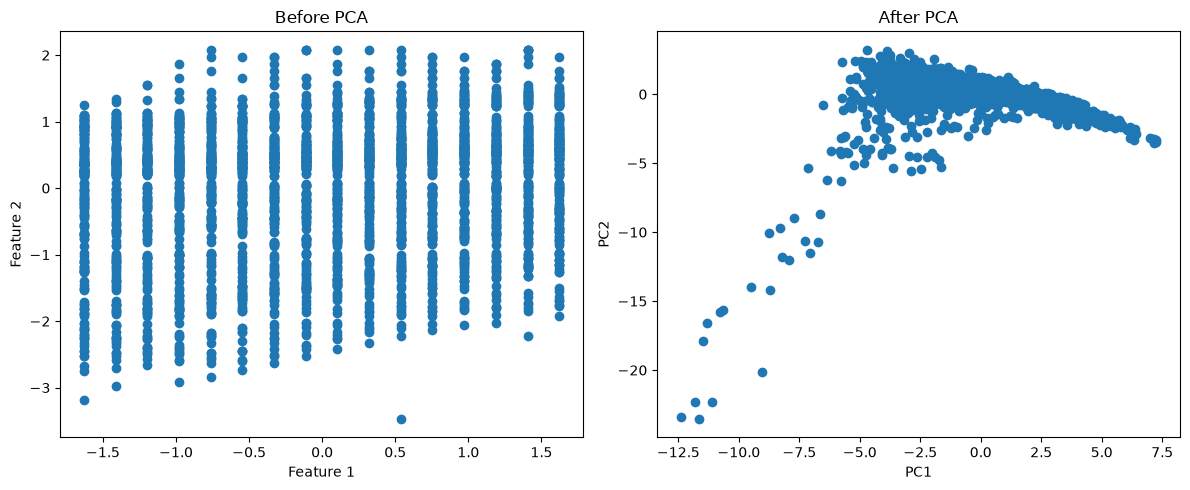

In [28]:
# Step 8: Visualize Before and After PCA

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Original standardized data
plt.subplot(1, 2, 1)
plt.scatter(
    standardized_data[:, 0],
    standardized_data[:, 1]
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Before PCA")

# Reduced PCA data
plt.subplot(1, 2, 2)
plt.scatter(
    reduced_data[:, 0],
    reduced_data[:, 1]
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("After PCA")

plt.tight_layout()
plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA:
Before PCA, the data is represented using the first two original features.
After PCA, the data is represented using PC1 and PC2.
The points remain the same observations, but their coordinates are transformed.
PC1 captures the largest direction of variance in the data.

2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making: 
The number of components was selected dynamically using a 95% cumulative explained variance threshold.
Keeping fewer components reduces the number of dimensions and simplifies the data.
However, removing components can cause some variance and information to be lost.
The trade-off is between reducing dimensionality and retaining as much information as possible.

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?:
The original dataset contains separate health, education, population, and economic indicators.
After PCA, these indicators are represented through combinations of principal components.
Some information contained in the dimensions that were removed is therefore lost.
In this analysis, approximately 3.92 of the variance is lost after dimensionality reduction.
